In [ ]:
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir = Path("/content/drive/MyDrive/ais") # adjust
df = pd.read_csv(base_dir / "LiteReviewerEvaluation.csv")
df

,Timestamp,1. [Clarity],1. [Usefulness],1. [Tone],1. [Correctness],2. [Clarity],2. [Usefulness],2. [Tone],2. [Correctness],3. [Clarity],...,11. [Correctness],12. [Clarity],12. [Usefulness],12. [Tone],12. [Correctness],13. What type of comments did you find most helpful?,14. What type of comments were least helpful?,15. Would you trust a tool like this in your coding workflow? Why or why not?,16. What should be improved in future versions of the tool?,17. Any additional thoughts?
0,2025/12/05 1:04:45 PM GMT+1,4,4,4,4,4,2,4,3,5,...,3,5,5,3,5,Optimization comments,Comments which explain something that has an e...,"No, the whole codebase is too big for the cont...",It shouldn't try to give comment about changin...,NaN
1,2025/12/06 1:36:51 PM GMT+1,4,3,4,3,5,4,4,4,4,...,4,4,4,2,4,comments which are about optimization are useful,Positive comments are not necessary,I would not totally trust and take action base...,The importance level might be given at the beg...,NaN
2,2025/12/07 6:12:39 PM GMT+1,3,3,4,3,3,3,4,2,4,...,5,5,5,5,5,The short comments with suggestions were helpf...,Redundant and lengthy comments with no actiona...,"Yes and no.\nYes, if I am the only developer o...",If tool is intended to give comment on styles ...,NaN
3,2025/12/09 8:33:34 PM GMT+1,4,5,5,5,5,5,5,5,3,...,5,4,4,5,5,Optimization suggestions,suggestions in Conditional statement,"Probably yes, but it will depends on other con...","May be adding Reasoning point, why the tool is...",good luck
4,2025/12/09 8:48:00 PM GMT+1,5,3,5,2,5,3,5,4,4,...,4,5,5,5,4,Comment with actionable steps to perform.,Code feedback without good suggestion or reaso...,"No, because LLMs can't get the context of the ...","More detailed explanation, or follow helpful t...",NaN
5,2025/12/09 9:36:52 PM GMT+1,4,3,3,4,4,3,3,3,3,...,4,5,5,5,5,logical bugs,suggestions,"no, the tools that only give verbal reviews ar...",suggestions should be improved further and inc...,NaN
6,2025/12/10 10:16:44 AM GMT+1,4,4,4,5,5,4,4,4,4,...,3,5,5,4,5,"The ones that give more context, letting the d...",The ones that just say that something may be w...,"Maybe, but such a tool may be a bit problemati...",I think it should be able to learn from certai...,NaN


In [ ]:
df.columns

Index(['Timestamp', '1. [Clarity]', '1. [Usefulness]', '1. [Tone]',
       '1. [Correctness]', '2. [Clarity]', '2. [Usefulness]', '2. [Tone]',
       '2. [Correctness]', '3. [Clarity]', '3. [Usefulness]', '3. [Tone]',
       '3. [Correctness]', '4. [Clarity]', '4. [Usefulness]', '4. [Tone]',
       '4. [Correctness]', '5. [Clarity]', '5. [Usefulness]', '5. [Tone]',
       '5. [Correctness]', '6. [Clarity]', '6. [Usefulness]', '6. [Tone]',
       '6. [Correctness]', '7. [Clarity]', '7. [Usefulness]', '7. [Tone]',
       '7. [Correctness]', '8. [Clarity]', '8. [Usefulness]', '8. [Tone]',
       '8. [Correctness]', '9. [Clarity]', '9. [Usefulness]', '9. [Tone]',
       '9. [Correctness]', '10. [Clarity]', '10. [Usefulness]', '10. [Tone]',
       '10. [Correctness]', '11. [Clarity]', '11. [Usefulness]', '11. [Tone]',
       '11. [Correctness]', '12. [Clarity]', '12. [Usefulness]', '12. [Tone]',
       '12. [Correctness]',
       '13. What type of comments did you find most helpful?',
     

In [ ]:
# Identify rating columns: they all match the pattern "number. [Aspect]"
pattern = r"^\d+\.\s*\[.*\]$"
rating_cols = [col for col in df.columns if re.match(pattern, col)]

# Extract question number and aspect for each column
def parse_col(col):
    # Example: "10. [Usefulness]"
    qnum = int(col.split(".")[0])
    aspect = col.split("[")[1].split("]")[0]
    return qnum, aspect

parsed = [parse_col(c) for c in rating_cols]

# Build a dataframe for means
means = df[rating_cols].mean().rename("mean_score").to_frame()

# Add parsed question and aspect
means["question"] = [q for (q, a) in parsed]
means["aspect"]   = [a for (q, a) in parsed]

# Sort for readability
means = means.sort_values(["question", "aspect"])

print("=== Mean score per question × aspect ===")
print(means)

# Pivot into matrix form: rows = question (1–12), columns = aspects
mean_matrix = means.pivot(index="question", columns="aspect", values="mean_score")

print("\n=== Matrix form ===")
print(mean_matrix)


=== Mean score per question × aspect ===
                   mean_score  question       aspect
1. [Clarity]         4.000000         1      Clarity
1. [Correctness]     3.714286         1  Correctness
1. [Tone]            4.142857         1         Tone
1. [Usefulness]      3.571429         1   Usefulness
2. [Clarity]         4.428571         2      Clarity
2. [Correctness]     3.571429         2  Correctness
2. [Tone]            4.142857         2         Tone
2. [Usefulness]      3.428571         2   Usefulness
3. [Clarity]         3.857143         3      Clarity
3. [Correctness]     3.857143         3  Correctness
3. [Tone]            3.857143         3         Tone
3. [Usefulness]      3.857143         3   Usefulness
4. [Clarity]         4.285714         4      Clarity
4. [Correctness]     3.428571         4  Correctness
4. [Tone]            4.000000         4         Tone
4. [Usefulness]      3.285714         4   Usefulness
5. [Clarity]         5.000000         5      Clarity
5. [C

/tmp/ipython-input-4175154838.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-4175154838.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-4175154838.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-4175154838.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-4175154838.py:28: FutureWarning: 

Passing `p

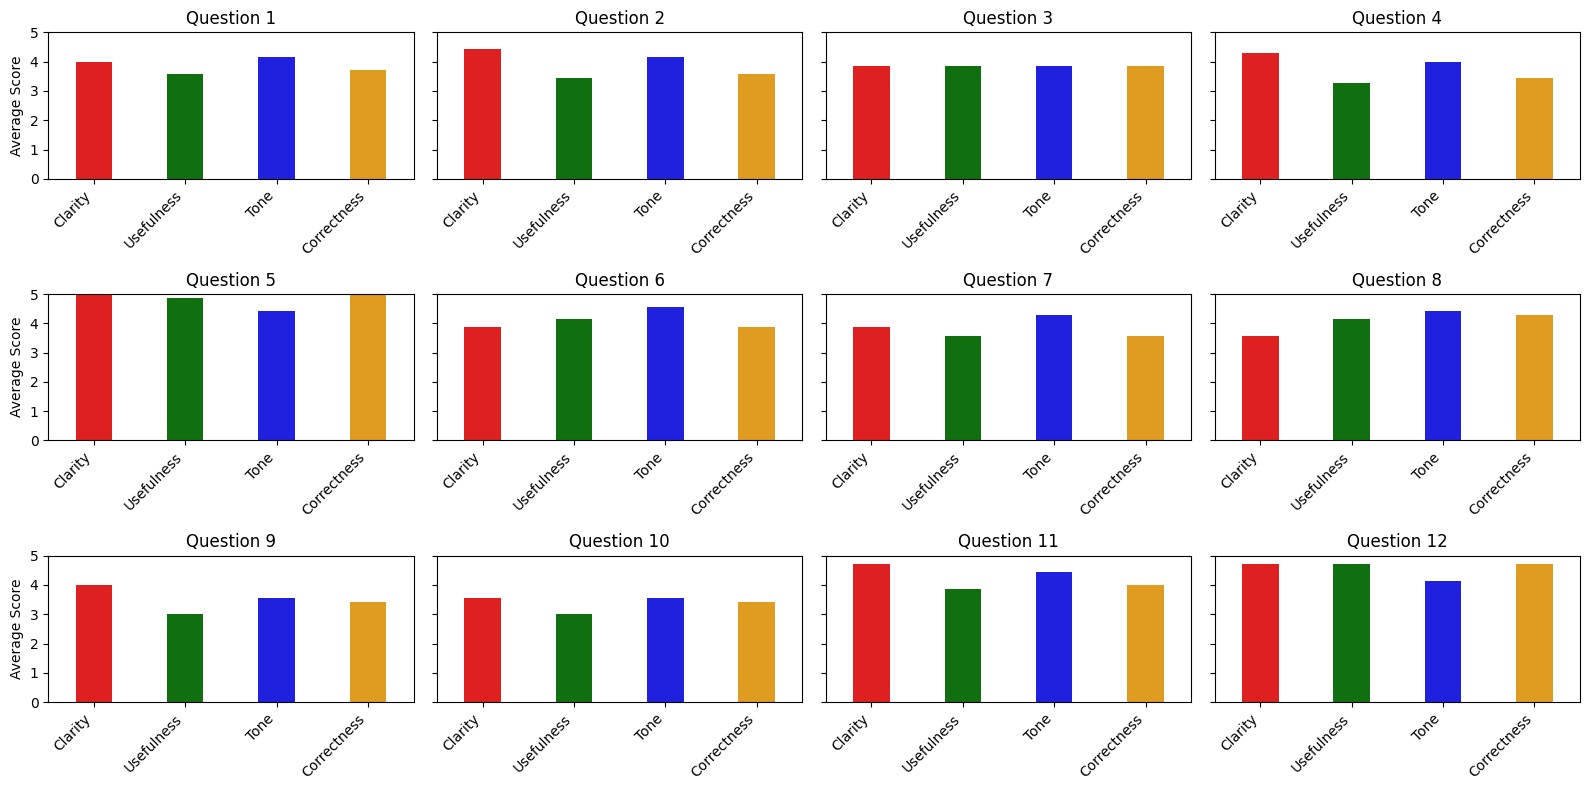

In [ ]:
# Fixed colors per aspect
aspect_colors = {
    "Clarity": "red",
    "Usefulness": "green",
    "Tone": "blue",
    "Correctness": "orange"
}

# Ensure consistent aspect ordering
aspects_order = ["Clarity", "Usefulness", "Tone", "Correctness"]

# Create 3x4 grid (12 subplots)
fig, axes = plt.subplots(3, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

questions = sorted(means["question"].unique())

for i, q in enumerate(questions):
    ax = axes[i]

    # Select and order the data for that question
    qdata = means[means["question"] == q].set_index("aspect").loc[aspects_order].reset_index()

    # Plot bars with thin width
    sns.barplot(
        data=qdata,
        x="aspect",
        y="mean_score",
        ax=ax,
        palette=[aspect_colors[a] for a in aspects_order],
        width=0.4
    )

    ax.set_title(f"Question {q}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Average Score")
    ax.set_ylim(0, 5)

    # Rotate x labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Remove empty subplot in case questions < 12 (not needed, but safe)
for j in range(len(questions), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/tmp/ipython-input-4263280117.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


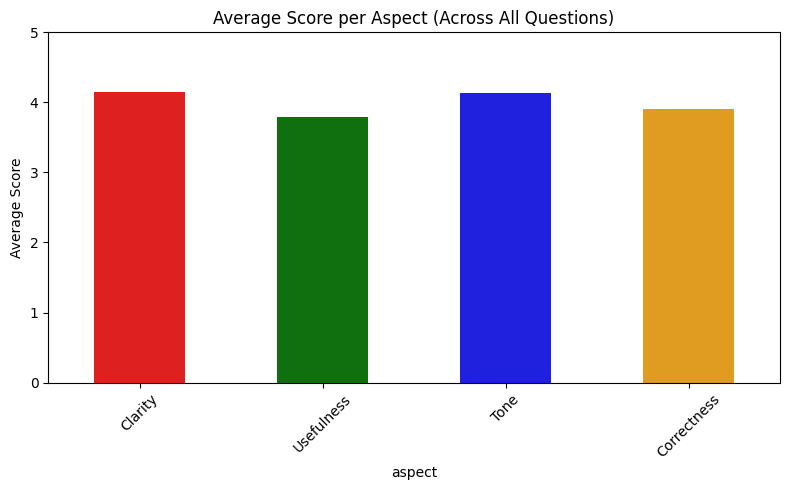

In [ ]:
# means dataframe already exists:
# columns: question, aspect, mean_score

# Compute overall average per aspect
aspect_avg = (
    means.groupby("aspect")["mean_score"]
    .mean()
    .reindex(["Clarity", "Usefulness", "Tone", "Correctness"])
)

# Aspect order and colors
aspect_colors = {
    "Clarity": "red",
    "Usefulness": "green",
    "Tone": "blue",
    "Correctness": "orange"
}

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    x=aspect_avg.index,
    y=aspect_avg.values,
    palette=[aspect_colors[a] for a in aspect_avg.index],
    width=0.5
)

plt.title("Average Score per Aspect (Across All Questions)")
plt.ylabel("Average Score")
plt.ylim(0, 5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Question → type mapping
question_type_mapping = {
    1: "security",
    2: "performance",
    3: "logic",
    4: "logic",
    5: "other",
    6: "other",
    7: "performance",
    8: "performance",
    9: "style",
    10: "documentation",
    11: "documentation",
    12: "logic"
}

# Add type column to means
means["type"] = means["question"].map(question_type_mapping)

# Compute average per (type, aspect)
type_aspect_avg = (
    means.groupby(["type", "aspect"])["mean_score"]
    .mean()
    .reset_index()
)


/tmp/ipython-input-1589353664.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1589353664.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-1589353664.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1589353664.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-1589353664.py:37: FutureWarning: 

Passing `p

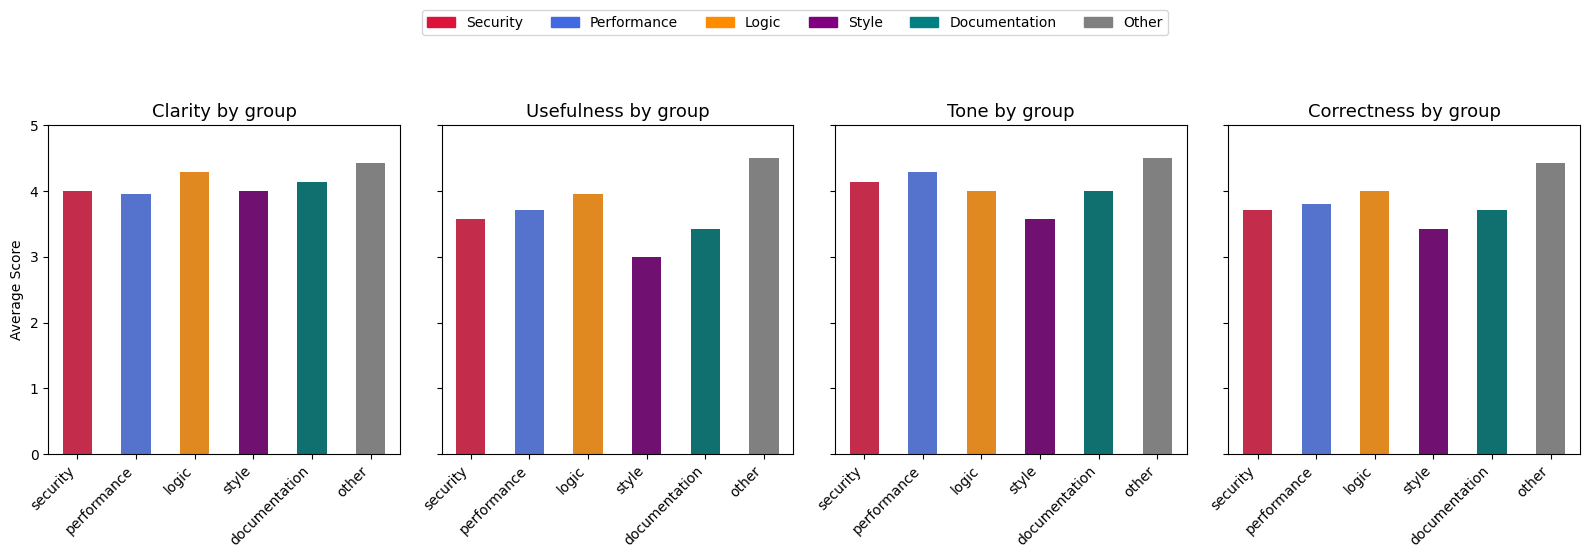

In [ ]:
# Fixed orderings
aspects_order = ["Clarity", "Usefulness", "Tone", "Correctness"]
types_order   = ["security", "performance", "logic", "style", "documentation", "other"]

# Colors per type
type_colors = {
    "security": "crimson",
    "performance": "royalblue",
    "logic": "darkorange",
    "style": "purple",
    "documentation": "teal",
    "other": "gray"
}

# Create 1x4 figure
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for i, aspect in enumerate(aspects_order):
    ax = axes[i]

    # Filter for this aspect
    adata = type_aspect_avg[type_aspect_avg["aspect"] == aspect].set_index("type")

    # Ensure consistent ordering
    adata = adata.reindex(types_order)

    # Build color palette in correct order
    palette = [type_colors[t] for t in types_order]

    sns.barplot(
        x=adata.index,
        y=adata["mean_score"].values,
        ax=ax,
        palette=palette,
        width=0.5
    )

    ax.set_title(f"{aspect} by group", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Average Score" if i == 0 else "")
    ax.set_ylim(0, 5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Global legend
legend_handles = [Patch(color=type_colors[t], label=t.capitalize()) for t in types_order]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=6,
    bbox_to_anchor=(0.5, 1.12)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
aspect_avg

,mean_score
aspect,
Clarity,4.154762
Usefulness,3.785714
Tone,4.130952
Correctness,3.904762


In [ ]:
table_df = (
    type_aspect_avg
        .pivot(index="type", columns="aspect", values="mean_score")
        .reindex(
            index=["security", "performance", "logic", "style", "documentation", "other"],
            columns=["Clarity", "Usefulness", "Tone", "Correctness"]
        )
)
table_df

aspect,Clarity,Usefulness,Tone,Correctness
type,,,,
security,4.000000,3.571429,4.142857,3.714286
performance,3.952381,3.714286,4.285714,3.809524
logic,4.285714,3.952381,4.000000,4.000000
style,4.000000,3.000000,3.571429,3.428571
documentation,4.142857,3.428571,4.000000,3.714286
other,4.428571,4.500000,4.500000,4.428571
